# Uncerstainty Analysis

In [26]:
# SI Figures: Correlated Uncertainty & Global Sensitivity (DiscountRate included)
# Single-process safe version (works around NumPy/SciPy ABI issues in subprocesses)

import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from scipy.stats import norm, spearmanr

# Patches/legend utilities
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

try:
    import seaborn as sns
    HAVE_SEABORN = True
except Exception:
    HAVE_SEABORN = False

plt.rcParams["figure.dpi"] = 150

# ==========================
# PATHS (READ ONLY)
# ==========================
BASE_ROOT = "/Users/amirgazar/Documents/GitHub/Decarbonization-Tradeoffs/3 Total Costs/10 Total Costs Results Final"
PER_SIM_FILE = "All_Costs_per_Simulation.csv"
PER_SIM_PATHS = {
    "1.5": os.path.join(BASE_ROOT, "discount rate 1.5 percent", PER_SIM_FILE),
    "2.0": os.path.join(BASE_ROOT, "discount rate 2 percent", PER_SIM_FILE),
    "2.5": os.path.join(BASE_ROOT, "discount rate 2.5 percent", PER_SIM_FILE),
}

# ==========================
# HARD-CODED COLUMNS
# ==========================
PATHWAY_COL  = "Pathway"
DRAW_COL     = "Simulation"
COST_COL     = "Total_Costs_mean_bUSD"

FUEL_mean, FUEL_min, FUEL_max     = "Fuel_mean_bUSD", "Fuel_min_bUSD", "Fuel_max_bUSD"
CAPEX_mean, CAPEX_min, CAPEX_max  = "CAPEX_mean_bUSD", "CAPEX_min_bUSD", "CAPEX_max_bUSD"

FEATURE_COLS = [
    "CAPEX_mean_bUSD",
    "FOM_mean_bUSD",
    "VOM_mean_bUSD",
    "Fuel_mean_bUSD",
    "Imports_mean_bUSD",
    "GHG_mean_bUSD",
    "Air_emissions_mean_bUSD",
    "Unmet_demand_mean_bUSD",
    "CAN_Imports_adj_mean_bUSD",
    "CAN_CAPEX_mean_bUSD",
    "CAN_FOM_mean_bUSD",
    "CAN_CH4_mean_bUSD",
]

# ==========================
# CONFIG
# ==========================
N_JOBS = 1
DR_LIST = ["1.5", "2.0", "2.5"]
DR_TO_FRACTION = lambda dr: float(dr) / 100.0

RF_KW_BASE = dict(n_estimators=700, min_samples_leaf=2, random_state=7, n_jobs=N_JOBS)
TEST_SIZE  = 0.25
RAND       = 7

# SI2 (not used here but kept intact)
SI2_MODE = "perm_fast"
SI2_MAX_ROWS = 40_000
SI2_BOOTSTRAPS = 8
RF_KW_SI2 = dict(n_estimators=400, min_samples_leaf=2, random_state=7, n_jobs=N_JOBS)

GROUP_RULES = {
    "Prices/Fuel":   [r"^Fuel_mean_bUSD$", r"price", r"fuel", r"ng", r"gas", r"import"],
    "CAPEX/O&M":     [r"^CAPEX_mean_bUSD$", r"^FOM_mean_bUSD$", r"^VOM_mean_bUSD$", r"capex", r"capital", r"(o&m|om)"],
    "Demand/System": [r"^Unmet_demand_mean_bUSD$", r"demand", r"load", r"reliab", r"outage"],
    "Emissions/Dmg": [r"^GHG_mean_bUSD$", r"^Air_emissions_mean_bUSD$", r"emission", r"damage"],
    "Finance":       [r"^DiscountRate$"],
    "Other":         [r".*"],
}

# ==========================
# HELPERS
# ==========================
def savefig_local(name):
    out = os.path.join(os.getcwd(), name)
    plt.tight_layout()
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[saved] {out}")

def exists(p): 
    return isinstance(p, str) and os.path.exists(p)

def triangular_ppf(u, a, m, b):
    a2 = np.minimum(a, np.minimum(m, b))
    b2 = np.maximum(a, np.maximum(m, b))
    m2 = np.clip(m, a2 + 1e-12, b2 - 1e-12)
    Fc = (m2 - a2) / (b2 - a2)
    out = np.empty_like(u, dtype=float)
    left = u < Fc
    out[left]  = a2[left] + np.sqrt(u[left]  * (b2[left] - a2[left]) * (m2[left] - a2[left]))
    out[~left] = b2[~left] - np.sqrt((1 - u[~left]) * (b2[~left] - a2[~left]) * (b2[~left] - m2[~left]))
    return out

def gaussian_copula_to_triangular(n, rho_fc, rho_fd, seed, fuel_params, capex_params, dr_pool):
    rng = np.random.default_rng(seed)
    R = np.array([[1.0,    rho_fc, rho_fd],
                  [rho_fc, 1.0,    0.0],
                  [rho_fd, 0.0,    1.0 ]], dtype=float)
    vals, vecs = np.linalg.eigh(R); vals[vals<1e-6] = 1e-6
    L = (vecs @ np.diag(np.sqrt(vals))).T
    Z = rng.standard_normal((n, 3))
    U = norm.cdf(Z @ L.T)

    Nrows = fuel_params["a"].shape[0]
    idx = rng.integers(0, Nrows, size=n)

    aF, mF, bF = fuel_params["a"][idx], fuel_params["m"][idx], fuel_params["b"][idx]
    Fuel_s = triangular_ppf(U[:,0], aF, mF, bF)

    aC, mC, bC = capex_params["a"][idx], capex_params["m"][idx], capex_params["b"][idx]
    CAPEX_s = triangular_ppf(U[:,1], aC, mC, bC)

    DR_sorted = np.sort(dr_pool)
    pos = np.minimum((U[:,2] * (len(DR_sorted)-1)).astype(int), len(DR_sorted)-1)
    DR_s = DR_sorted[pos]
    return Fuel_s, CAPEX_s, DR_s

# ==========================
# LOAD DATA
# ==========================
frames = []
for dr in DR_LIST:
    p = PER_SIM_PATHS[dr]
    if exists(p):
        d = pd.read_csv(p)
        d["DiscountRate"] = DR_TO_FRACTION(dr)  # 0.015 / 0.02 / 0.025
        d["_DR_Label"] = f"{dr}%"
        frames.append(d)
    else:
        print(f"[skip DR={dr}] missing file: {p}")
if not frames:
    raise FileNotFoundError("No per-simulation CSVs found at your Mac paths.")

df = pd.concat(frames, ignore_index=True)
print(f"Combined rows={len(df):,}, cols={len(df.columns)}")

need_cols = ["Pathway","Simulation","Total_Costs_mean_bUSD",
             "Fuel_min_bUSD","Fuel_mean_bUSD","Fuel_max_bUSD",
             "CAPEX_min_bUSD","CAPEX_mean_bUSD","CAPEX_max_bUSD","DiscountRate"]
miss = [c for c in need_cols if c not in df.columns]
if miss:
    raise ValueError(f"Missing required columns: {miss}")

feat_cols = ["DiscountRate"] + [c for c in FEATURE_COLS if c in df.columns]
feat_cols = list(dict.fromkeys(feat_cols))
base_df = df.dropna(subset=feat_cols + ["Total_Costs_mean_bUSD"]).copy()

# ==========================
# SI1 — Spearman correlation (clustered), NO cbar in main; separate skinny colorbar SVG
# ==========================
from scipy.cluster.hierarchy import linkage
import matplotlib.gridspec as gridspec

def _pretty_label(s: str) -> str:
    return (s.replace("_mean_bUSD", "")
             .replace("_adj_", " ").replace("_bUSD", "")
             .replace("_CH4_", " CH4 ").replace("_CAPEX_", " CAPEX ")
             .replace("_FOM_", " FOM ").replace("_VOM_", " VOM ")
             .replace("_Imports_", " Imports ").replace("_", " ")
             .replace("DiscountRate", "Discount rate")
             .strip())

def _wrap(text, width=16):
    out, line = [], ""
    for w in text.split():
        add = "" if not line else " "
        if len(line) + len(w) + len(add) <= width:
            line = f"{line}{add}{w}"
        else:
            out.append(line); line = w
    if line: out.append(line)
    return "\n".join(out)

SHOW_SIGNIFICANCE_X = True
X_FONTSIZE = 14
LIGHT_GRAY = "#d9d9d9"

# Filter + ordering (Canada removed; order list only constrains which vars are included)
feat_cols_nocan = [c for c in feat_cols if not c.startswith("CAN_")]
order_map = [
    "CAPEX_mean_bUSD", "FOM_mean_bUSD", "VOM_mean_bUSD",
    "Fuel_mean_bUSD", "Imports_mean_bUSD", "GHG_mean_bUSD",
    "Air_emissions_mean_bUSD", "Unmet_demand_mean_bUSD", "DiscountRate"
]
ordered_cols = [c for c in order_map if c in feat_cols_nocan]
if len(ordered_cols) < 2:
    print("[skip SI1] not enough variables after filtering.")
else:
    rho, pvals = spearmanr(base_df[ordered_cols])
    rho = np.clip(rho, -1, 1)
    labels = [_wrap(_pretty_label(c), 16) for c in ordered_cols]
    corr_df = pd.DataFrame(rho, index=labels, columns=labels)
    pval_df = pd.DataFrame(pvals, index=labels, columns=labels)

    if HAVE_SEABORN:
        sns.set_theme(context="paper", style="white", font_scale=1.05)
        # Green = +1, Red = −1
        cmap_rg = sns.diverging_palette(10, 130, s=90, l=55, as_cmap=True)

        # --- Clustered heatmap with dendrograms; NO colorbar here ---
        cg = sns.clustermap(
            corr_df, method="average", metric="euclidean",
            cmap=cmap_rg, center=0, vmin=-1, vmax=1,
            linewidths=0, linecolor=None, square=True,
            figsize=(9.0, 8.4),
            cbar_pos=None,                 # <-- keep main figure free of any colorbar
            dendrogram_ratio=(0.09, 0.09),
            xticklabels=True, yticklabels=True
        )
        ax = cg.ax_heatmap
        row_ind = cg.dendrogram_row.reordered_ind
        col_ind = cg.dendrogram_col.reordered_ind
        n = corr_df.shape[0]

        # Put ticks at centers; draw a single crisp grid at integer edges
        ax.set_xlim(0, n); ax.set_ylim(n, 0)
        ax.set_xticks(np.arange(n) + 0.5)
        ax.set_yticks(np.arange(n) + 0.5)
        ax.set_xticklabels([corr_df.columns[i] for i in col_ind], rotation=30, ha="right")
        ax.set_yticklabels([corr_df.index[i]   for i in row_ind], rotation=0)
        for i in range(n + 1):
            ax.axhline(i, color="white", lw=0.8, zorder=11)
            ax.axvline(i, color="white", lw=0.8, zorder=11)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Light-gray diagonal squares (aligned to clustered order)
        row_pos = {orig: pos for pos, orig in enumerate(row_ind)}
        col_pos = {orig: pos for pos, orig in enumerate(col_ind)}
        for orig in range(n):
            xi = col_pos[orig]; yi = row_pos[orig]
            rect = mpatches.Rectangle((xi, yi), 1, 1,
                                      facecolor=LIGHT_GRAY, edgecolor="gray",
                                      linewidth=0.6, hatch="///", zorder=12)
            ax.add_patch(rect)

        # Larger “×” for non-significant off-diagonals (p > 0.05)
        if SHOW_SIGNIFICANCE_X:
            for i_orig in range(n):
                for j_orig in range(n):
                    if i_orig == j_orig:
                        continue
                    pv = pval_df.iloc[i_orig, j_orig]
                    if np.isfinite(pv) and pv > 0.05:
                        ax.text(col_pos[j_orig] + 0.5, row_pos[i_orig] + 0.5, "×",
                                ha="center", va="center", color="black",
                                fontsize=X_FONTSIZE, zorder=13)

        # Slim dendrogram lines
        for da in [cg.ax_row_dendrogram, cg.ax_col_dendrogram]:
            for line in da.collections:
                line.set_linewidth(1.0)

        cg.fig.subplots_adjust(left=0.18, right=0.98, top=0.98, bottom=0.16)

        # --- Save main figure (no colorbar) ---
        out_main = "Fig_SI1_Correlation_Spearman_Clustered_LightDiag_NoCbar.svg"
        cg.savefig(out_main, dpi=300, bbox_inches="tight")
        print(f"[saved] {os.path.join(os.getcwd(), out_main)}")

        # --- Save a separate skinny vertical colorbar with SAME HEIGHT as main ---
        # Match main figure height exactly (inches); make the colorbar very narrow
        main_w_in, main_h_in = cg.fig.get_size_inches()
        CBAR_WIDTH_IN = 0.5   # << adjust this to make it thinner/thicker as you like
        ticks = np.round(np.arange(-1.0, 1.0001, 0.25), 2)
        norm = plt.Normalize(vmin=-1, vmax=1)
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_rg)

        fig_cb, ax_cb = plt.subplots(figsize=(CBAR_WIDTH_IN, float(main_h_in)))
        cb = plt.colorbar(sm, cax=ax_cb, orientation="vertical", ticks=ticks)
        cb.ax.tick_params(labelsize=9, right=True, labelright=True, left=False, labelleft=False)
        cb.set_label("Spearman ρ", rotation=270, labelpad=12)
        fig_cb.savefig("Fig_SI1_Colorbar.svg", dpi=300, bbox_inches="tight")
        plt.close(fig_cb)
        plt.close(cg.fig)
        print("[saved] Fig_SI1_Colorbar.svg")
    else:
        print("Seaborn not available.")



Combined rows=26,892, cols=46
[saved] /Users/amirgazar/Documents/GitHub/Decarbonization-Tradeoffs/6 Figures/Uncertainty/Fig_SI1_Correlation_Spearman_Clustered_LightDiag_NoCbar.svg
[saved] Fig_SI1_Colorbar.svg


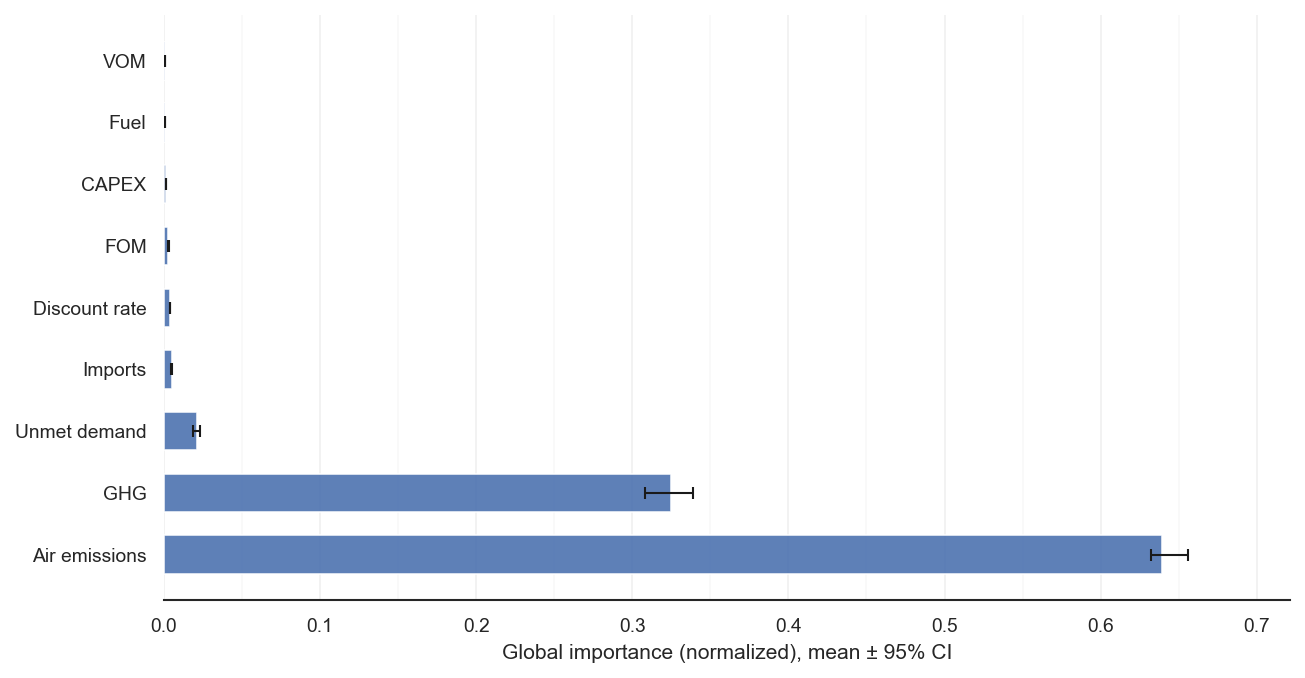

[saved] /Users/amirgazar/Documents/GitHub/Decarbonization-Tradeoffs/6 Figures/Uncertainty/Fig_SI2_Global_Sensitivity_PermFast.svg


In [38]:
# ==========================
# SI2 — Global sensitivity (fast, single-process) — Improved & CAN_ excluded
# ==========================

def _spearman_topk(df0, features, target, k=12):
    vals = []
    for f in features:
        if f.startswith("CAN_"):   # exclude Canada vars directly
            continue
        try:
            r = spearmanr(df0[f], df0[target], nan_policy="omit").correlation
        except Exception:
            r = np.nan
        vals.append((f, abs(r if np.isfinite(r) else 0)))
    feats_sorted = [t[0] for t in sorted(vals, key=lambda x: x[1], reverse=True)]
    return feats_sorted[:min(k, len(feats_sorted))]

# ---------- Improved plotting helper ----------
def _plot_importance_ci(df_imp, _title_unused, fname, top_k=12):
    import os
    import matplotlib as mpl
    from matplotlib.ticker import MultipleLocator

    mpl.rcParams.update({
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.spines.bottom": True,
        "figure.dpi": 150,
        "font.size": 10,
    })

    # Pretty short labels
    def _pretty_label(s: str) -> str:
        return (s.replace("_mean_bUSD", "")
                 .replace("_adj_", " ")
                 .replace("_bUSD", "")
                 .replace("_CH4_", " CH4 ")
                 .replace("_CAPEX_", " CAPEX ")
                 .replace("_FOM_", " FOM ")
                 .replace("_VOM_", " VOM ")
                 .replace("_Imports_", " Imports ")
                 .replace("_", " ")
                 .replace("DiscountRate", "Discount rate")
                 .strip())

    d = df_imp.copy()

    # Exclude Canada variables from plot too
    d = d[~d["feature"].str.startswith("CAN_")]

    # Sort largest → smallest
    d = d.sort_values("mean", ascending=False).head(min(top_k, len(d))).copy()

    # 95% CI
    lo = np.clip(d["mean"].to_numpy() - d["p025"].to_numpy(), 0, None)
    hi = np.clip(d["p975"].to_numpy() - d["mean"].to_numpy(), 0, None)
    xerr = np.vstack([lo, hi])

    # Figure layout
    fig_w, fig_h = 8.8, max(4.4, 0.38 * len(d) + 1.2)
    plt.figure(figsize=(fig_w, fig_h))
    y = np.arange(len(d))[::-1]
    means = d["mean"].to_numpy()[::-1]
    xerr_plot = xerr[:, ::-1]
    labels = d["feature"].apply(_pretty_label).tolist()[::-1]

    # Bars
    plt.barh(
        y, means, xerr=xerr_plot,
        height=0.62, alpha=0.9, color="#4c72b0",
        error_kw=dict(ecolor="k", lw=1, capsize=3)
    )

    plt.yticks(y, labels)
    plt.xlabel("Global importance (normalized), mean ± 95% CI")

    ax = plt.gca()
    ax.grid(axis="x", which="major", alpha=0.30)
    ax.grid(axis="x", which="minor", alpha=0.12)
    ax.xaxis.set_major_locator(MultipleLocator(0.10))
    ax.xaxis.set_minor_locator(MultipleLocator(0.05))
    xmax = float(max(0.08, np.nanmax(d["p975"]) * 1.10))
    ax.set_xlim(0, xmax)

    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[saved] {os.path.join(os.getcwd(), fname)}")

# ---------- Compute SI2 exactly as before (uses improved plotter) ----------
base_df_si2 = base_df.sample(min(len(base_df), SI2_MAX_ROWS), random_state=RAND).copy()
feat_si2 = _spearman_topk(base_df_si2, feat_cols, COST_COL, k=12)
X_all = base_df_si2[feat_si2].values
y_all = base_df_si2[COST_COL].values

mode_used = SI2_MODE

if SI2_MODE == "shap":
    try:
        import shap
        rf = RandomForestRegressor(**RF_KW_SI2).fit(X_all, y_all)
        explainer = shap.TreeExplainer(rf, feature_names=feat_si2)
        n_bg = min(2000, len(base_df_si2))
        X_bg = base_df_si2[feat_si2].sample(n_bg, random_state=RAND).values
        shap_vals = explainer.shap_values(X_bg, check_additivity=False)
        mean_abs = np.abs(shap_vals).mean(axis=0)

        rng = np.random.default_rng(RAND)
        boots = []
        for b in range(SI2_BOOTSTRAPS):
            pick = rng.integers(0, n_bg, size=n_bg)
            boots.append(np.abs(shap_vals[pick]).mean(axis=0))
        B = np.vstack(boots)

        denom = mean_abs.sum() + 1e-12
        out = pd.DataFrame({
            "feature": feat_si2,
            "mean": mean_abs / denom,
            "p025": np.quantile(B, 0.025, axis=0) / denom,
            "p975": np.quantile(B, 0.975, axis=0) / denom,
        })
        _plot_importance_ci(out, "Fig SI2 — Global sensitivity (TreeSHAP, normalized)",
                            "Fig_SI2_Global_Sensitivity_SHAP.svg")
    except Exception as e:
        print(f"[SI2 shap] falling back to perm_fast due to: {e}")
        mode_used = "perm_fast"

if mode_used == "perm_fast":
    from sklearn.inspection import permutation_importance
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.25, random_state=RAND)
    rf = RandomForestRegressor(**RF_KW_SI2).fit(X_tr, y_tr)

    perm = permutation_importance(rf, X_te, y_te, n_repeats=10,
                                  random_state=RAND, n_jobs=N_JOBS)
    mean = perm.importances_mean

    rng = np.random.default_rng(RAND)
    boots = []
    n_te = len(X_te)
    for b in range(SI2_BOOTSTRAPS):
        pick = rng.integers(0, n_te, size=min(n_te, 4000))
        pb = permutation_importance(rf, X_te[pick], y_te[pick], n_repeats=6,
                                    random_state=RAND+b, n_jobs=N_JOBS)
        boots.append(pb.importances_mean)
    B = np.vstack(boots)

    denom = mean.sum() + 1e-12
    out = pd.DataFrame({
        "feature": feat_si2,
        "mean": mean / denom,
        "p025": np.quantile(B, 0.025, axis=0) / denom,
        "p975": np.quantile(B, 0.975, axis=0) / denom,
    })
    _plot_importance_ci(out, "Fig SI2 — Global sensitivity (Permutation, fast)",
                        "Fig_SI2_Global_Sensitivity_PermFast.svg")

if mode_used == "rf_builtin":
    rf = RandomForestRegressor(**RF_KW_SI2).fit(X_all, y_all)
    fi = rf.feature_importances_

    rng = np.random.default_rng(RAND)
    boots = []
    for b in range(SI2_BOOTSTRAPS):
        pick = rng.integers(0, len(base_df_si2), size=len(base_df_si2))
        Xb, yb = X_all[pick], y_all[pick]
        rf_b = RandomForestRegressor(**RF_KW_SI2).fit(Xb, yb)
        boots.append(rf_b.feature_importances_)
    B = np.vstack(boots)

    denom = fi.sum() + 1e-12
    out = pd.DataFrame({
        "feature": feat_si2,
        "mean": fi / denom,
        "p025": np.quantile(B, 0.025, axis=0) / denom,
        "p975": np.quantile(B, 0.975, axis=0) / denom,
    })
    _plot_importance_ci(out, "Fig SI2 — Global sensitivity (RF built-in, normalized)",
                        "Fig_SI2_Global_Sensitivity_RFBuiltIn.svg")


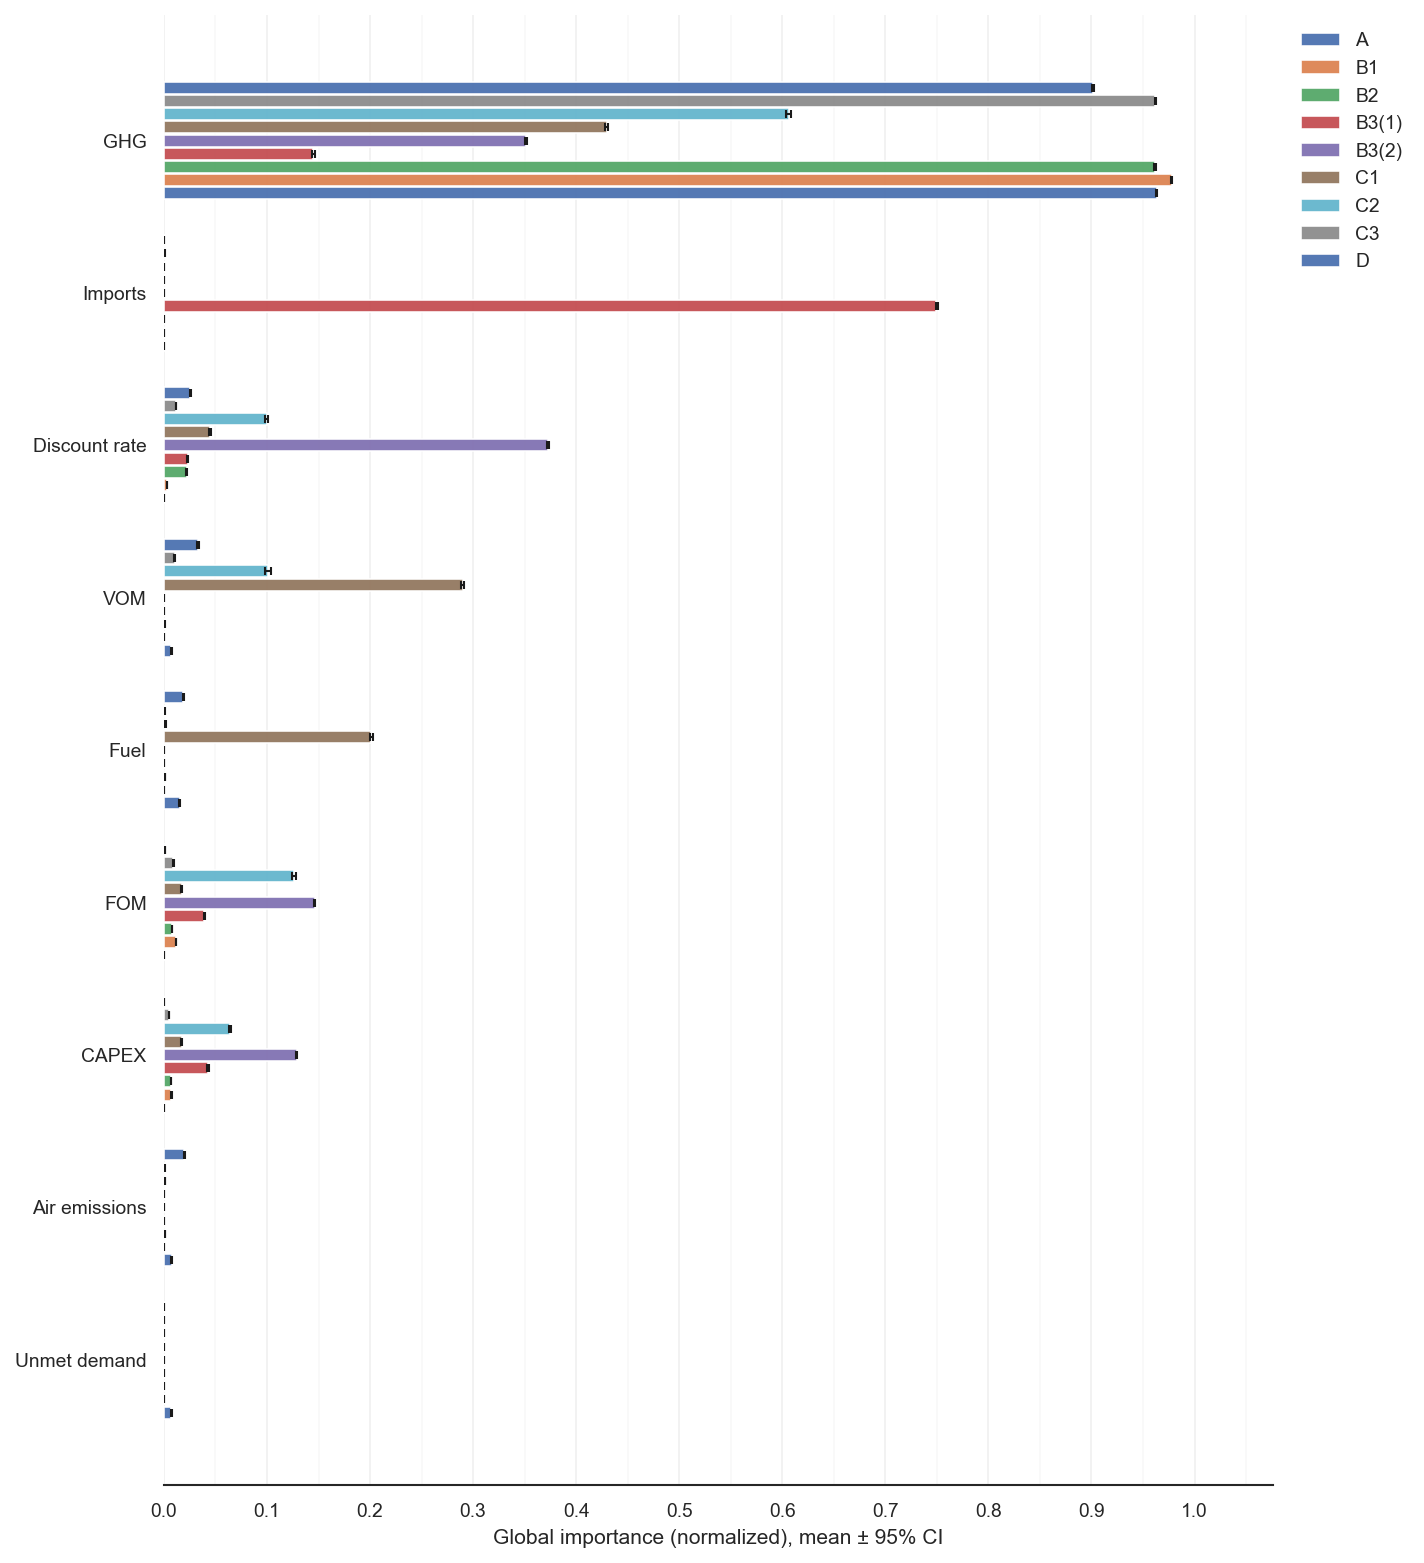

[saved] Fig_SI2_Global_Sensitivity_byPathway.svg


In [57]:
# ==============================================================
# SI2 — Global sensitivity per Pathway (grouped bars, fixed CIs)
# - Uses permutation importance (fast) with per-draw normalization
# - Excludes CAN_* variables everywhere
# - One bar per Pathway for each top feature
# - Bars scaled thicker (bar_scale) without overlap
#
# Assumes these already exist in your notebook/script:
#   base_df, PATHWAY_COL, COST_COL, feat_cols,
#   SI2_MAX_ROWS, RAND, N_JOBS, SI2_BOOTSTRAPS, RF_KW_SI2
# ==============================================================

from collections import OrderedDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

# ---- helpers --------------------------------------------------

def _pretty_label(s: str) -> str:
    return (s.replace("_mean_bUSD", "")
             .replace("_adj_", " ")
             .replace("_bUSD", "")
             .replace("_CH4_", " CH4 ")
             .replace("_CAPEX_", " CAPEX ")
             .replace("_FOM_", " FOM ")
             .replace("_VOM_", " VOM ")
             .replace("_Imports_", " Imports ")
             .replace("_", " ")
             .replace("DiscountRate", "Discount rate")
             .strip())

def _spearman_topk_excl_can(df0, features, target, k=12):
    """Rank features by |Spearman r| (excluding CAN_*) and return top-k names."""
    vals = []
    for f in features:
        if f.startswith("CAN_"):
            continue
        try:
            r = spearmanr(df0[f], df0[target], nan_policy="omit").correlation
        except Exception:
            r = np.nan
        vals.append((f, abs(r if np.isfinite(r) else 0)))
    feats_sorted = [t[0] for t in sorted(vals, key=lambda x: x[1], reverse=True)]
    return feats_sorted[:min(k, len(feats_sorted))]

def _compute_si2_perm_fast_norm(df_in, feature_pool, target_col, k=12):
    """
    Permutation importance with bootstrap CIs.
    - Samples rows (<= SI2_MAX_ROWS)
    - Selects top-k by |Spearman|
    - For each bootstrap draw, recomputes permutation importance and NORMALIZES
      the importance vector to sum to 1 before storing.
    Returns DataFrame(feature, mean, p025, p975) or None if not enough data.
    """
    if df_in is None or len(df_in) < 25:
        return None

    d = df_in.sample(min(len(df_in), SI2_MAX_ROWS), random_state=RAND).copy()
    feat_sel = _spearman_topk_excl_can(d, feature_pool, target_col, k=k)
    if len(feat_sel) < 2:
        return None

    X = d[feat_sel].values
    y = d[target_col].values

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=RAND)
    rf = RandomForestRegressor(**RF_KW_SI2).fit(X_tr, y_tr)

    # Bootstrap draws — normalize each draw
    rng = np.random.default_rng(RAND)
    boots_norm = []
    n_te = len(X_te)
    for b in range(SI2_BOOTSTRAPS):
        pick = rng.integers(0, n_te, size=min(n_te, 4000))
        pb = permutation_importance(
            rf, X_te[pick], y_te[pick],
            n_repeats=6, random_state=RAND + b, n_jobs=N_JOBS
        )
        v = pb.importances_mean
        v = v / (v.sum() + 1e-12)
        boots_norm.append(v)

    Bn = np.vstack(boots_norm)
    return pd.DataFrame({
        "feature": feat_sel,
        "mean":  Bn.mean(axis=0),
        "p025":  np.quantile(Bn, 0.025, axis=0),
        "p975":  np.quantile(Bn, 0.975, axis=0),
    })

def plot_grouped_global_sensitivity_by_pathway(
    out_by_pathway: "OrderedDict[str, pd.DataFrame]",
    fname="Fig_SI2_Global_Sensitivity_byPathway.svg",
    top_k=12,
    bar_alpha=0.9,
    bar_scale=3.0,     # visually 3× thicker groups (no bar overlap)
    palette=None
):
    """
    Grouped horizontal bars: one bar per pathway for each top feature.
    Feature list chosen by taking the max mean across pathways, then top_k.
    bar_scale controls vertical expansion of each feature row (make bigger bars).
    """
    mpl.rcParams.update({
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.spines.bottom": True,
        "figure.dpi": 150,
        "font.size": 10,
    })

    # Harmonize features across pathways, exclude CAN_ defensively
    processed = {}
    all_rows = []
    for pw, df in out_by_pathway.items():
        if df is None or len(df) == 0:
            continue
        d = df.copy()
        d = d[~d["feature"].str.startswith("CAN_")]
        d = d.assign(pretty=d["feature"].apply(_pretty_label))
        processed[pw] = d
        all_rows.append(d[["pretty", "mean"]])

    if not processed:
        print("[plot] No pathway results to plot.")
        return

    # Pick top_k features by maximum mean across pathways
    full = pd.concat(all_rows, axis=0)
    feat_order = (full.groupby("pretty")["mean"]
                      .max()
                      .sort_values(ascending=False)
                      .head(top_k)
                      .index
                      .tolist())

    pathways = list(processed.keys())
    S = len(pathways)

    # Build arrays per pathway in the same feature order
    rows = []
    for pw in pathways:
        d = processed[pw].set_index("pretty")
        mean = d.reindex(feat_order).get("mean", pd.Series(0, index=feat_order)).fillna(0).values
        p025 = d.reindex(feat_order).get("p025", pd.Series(0, index=feat_order)).fillna(0).values
        p975 = d.reindex(feat_order).get("p975", pd.Series(0, index=feat_order)).fillna(0).values
        rows.append((pw, mean, p025, p975))

    # Figure geometry
    n = len(feat_order)
    # Base group height ~0.78; scale by bar_scale to make rows visually taller (≈ “3× bigger”)
    group_h = 0.78 * bar_scale
    bar_h   = group_h / S

    fig_w = 9.6
    fig_h = max(4.8, (group_h + 0.30) * n + 0.8)  # height grows with thicker rows
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # Y positions: one center per feature, then bars within the group
    y_centers = np.arange(n)[::-1]  # top = largest
    # Palette
    if palette is None:
        palette = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b2",
                   "#937860", "#64b5cd", "#8c8c8c"]
    colors = {pw: palette[i % len(palette)] for i, pw in enumerate(pathways)}

    # Draw bars + error whiskers
    xmax_guess = 0.0
    for i, (pw, mean, p025, p975) in enumerate(rows):
        lo = np.clip(mean - p025, 0, None)
        hi = np.clip(p975 - mean, 0, None)
        y = y_centers + (i - (S - 1) / 2) * bar_h

        ax.barh(y, mean, height=bar_h * 0.9,   # 90% of local slot; bar_scale gives the visual thickness
                color=colors[pw], alpha=bar_alpha, label=pw)
        ax.errorbar(mean, y, xerr=[lo, hi], fmt="none",
                    ecolor="k", elinewidth=1, capsize=2, capthick=1)
        xmax_guess = max(xmax_guess, float(np.nanmax(p975) if np.size(p975) else 0))

    # Y ticks & labels
    ax.set_yticks(y_centers)
    ax.set_yticklabels(feat_order)

    # Grid and x-axis
    ax.grid(axis="x", which="major", alpha=0.30)
    ax.grid(axis="x", which="minor", alpha=0.12)
    ax.xaxis.set_major_locator(MultipleLocator(0.10))
    ax.xaxis.set_minor_locator(MultipleLocator(0.05))
    ax.set_xlim(0, max(0.08, xmax_guess * 1.10))
    ax.set_xlabel("Global importance (normalized), mean ± 95% CI")

    # Legend outside right
    handles = [mpl.patches.Patch(facecolor=colors[pw], label=pw, alpha=bar_alpha) for pw in pathways]
    ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1.01, 1),
              loc="upper left", title=None)

    fig.tight_layout()
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[saved] {fname}")


# ---- compute per-pathway outs & plot --------------------------

# Choose which pathways to include (all by default)
pathways_available = [p for p in sorted(base_df[PATHWAY_COL].dropna().unique().tolist())]

outs_by_pathway = OrderedDict()
for pw in pathways_available:
    df_pw = base_df[base_df[PATHWAY_COL] == pw]
    out_pw = _compute_si2_perm_fast_norm(df_pw, feat_cols, COST_COL, k=12)
    if out_pw is not None and len(out_pw):
        outs_by_pathway[pw] = out_pw

# Plot grouped figure (3× thicker rows, no overlap)
plot_grouped_global_sensitivity_by_pathway(
    outs_by_pathway,
    fname="Fig_SI2_Global_Sensitivity_byPathway.svg",
    top_k=12,
    bar_alpha=0.95,
    bar_scale=1.0,   # visually “×3” rows
)
